In [ ]:
import pandas as pd
import re
import os
import numpy as np
from random import random

os.environ["WANDB_DISABLED"] = "true"

from google.colab import drive
from sklearn.model_selection import KFold
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from datasets import Dataset
import torch
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sentence_transformers import SentenceTransformer, util

# ================================
# Mount Drive
# ================================
drive.mount('/content/drive')

# ================================
# Load Dataset
# ================================
file_path = '/content/drive/MyDrive/data2/mixeddataset.xlsx'
df = pd.read_excel(file_path)

# Clean column names
df.columns = (
    df.columns.astype(str)
      .str.strip()
      .str.lower()
      .str.replace('\ufeff', '', regex=False)
)

print("Columns:", df.columns.tolist())

# ================================
# Preprocess
# ================================
def preprocess_text(text):
    if isinstance(text, str):
        text = re.sub(r'[^\u0000-\u007F]+', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return ' '.join(text.split()[:500])
    return ''

df['subject'] = df['subject'].apply(preprocess_text)
df['body'] = df['body'].apply(preprocess_text)

df['text'] = df['subject'] + " " + df['body']
df['label'] = df['label'].astype(int)

df = df.dropna(subset=['text', 'label'])
df = df[df['text'].str.strip() != '']
df = df[~df['text'].str.contains('#ERROR!', na=False)]

# ================================
# Label Noise (5%)
# ================================
def add_label_noise(label, noise_rate=0.05):
    return 1 - label if random() < noise_rate else label

df['label'] = df['label'].apply(add_label_noise)

# ================================
# Remove duplicates
# ================================
df = df.drop_duplicates(subset=['text'])

# ================================
# Remove near duplicates
# ================================
print("Removing near duplicates...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = embedder.encode(df['text'].tolist(), batch_size=32, show_progress_bar=True)

cos_sim = util.cos_sim(embeddings, embeddings)
threshold = 0.90

near_duplicates = set()
for i in range(len(cos_sim)):
    for j in range(i+1, len(cos_sim)):
        if cos_sim[i][j] > threshold:
            near_duplicates.add(j)

df = df.drop(index=df.index[list(near_duplicates)])

# ================================
# Tokenizer
# ================================
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=512
    )

# ================================
# Metrics
# ================================
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}

# ================================
# 5-Fold CV
# ================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_metrics = []

for fold, (train_idx, val_idx) in enumerate(kf.split(df)):
    print(f"\n===== Fold {fold+1} =====")

    train_df = df.iloc[train_idx]
    val_df = df.iloc[val_idx]

    train_dataset = Dataset.from_pandas(train_df[['text', 'label']])
    val_dataset = Dataset.from_pandas(val_df[['text', 'label']])

    train_dataset = train_dataset.map(tokenize_function, batched=True)
    val_dataset = val_dataset.map(tokenize_function, batched=True)

    train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
    val_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

    model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

    # Freeze first 3 layers
    for param in model.distilbert.transformer.layer[:3].parameters():
        param.requires_grad = False

    training_args = TrainingArguments(
        output_dir=f'/content/drive/MyDrive/bertmixeddataset/distilbertfolder/fold_{fold+1}',
        num_train_epochs=3,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        weight_decay=0.1,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        logging_steps=50
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

    trainer.train()
    fold_metrics.append(trainer.evaluate())

# ================================
# Final Training
# ================================
dataset = Dataset.from_pandas(df[['text', 'label']])
split = dataset.train_test_split(test_size=0.2, seed=42)

train_dataset = split['train'].map(tokenize_function, batched=True)
val_dataset = split['test'].map(tokenize_function, batched=True)

train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])

model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)

for param in model.distilbert.transformer.layer[:3].parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='/content/drive/MyDrive/bertmixeddataset/distilbertfolder',
    num_train_epochs=3,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=50
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

trainer.train()

# ================================
# Save Model
# ================================
model.save_pretrained('/content/drive/MyDrive/bertmixeddataset/distilbertfolder')
tokenizer.save_pretrained('/content/drive/MyDrive/bertmixeddataset/distilbertfolder')

print("\n✅ DistilBERT training complete & saved to Drive!")


Mounted at /content/drive
Columns: ['subject', 'body', 'label']
Removing near duplicates...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Map:   0%|          | 0/3018 [00:00<?, ? examples/s]

Map:   0%|          | 0/755 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.265700,0.389324,0.901987,0.890339,0.914209,0.902116
2,0.265500,0.322273,0.909934,0.902375,0.916890,0.909574
3,0.248300,0.347552,0.919205,0.919355,0.916890,0.918121



✅ DistilBERT training complete & saved to Drive!


In [ ]:
# ============================================
# STEP 1: Mount Google Drive (MANDATORY)
# ============================================
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# (Optional but recommended) Verify files exist
!ls /content/drive/MyDrive/bertmixeddataset/distilbertfolder


# ============================================
# STEP 2: Import required libraries
# ============================================
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
import torch


# ============================================
# STEP 3: Load fine-tuned DistilBERT (LOCAL ONLY)
# ============================================
model_path = "/content/drive/MyDrive/bertmixeddataset/distilbertfolder"

tokenizer = DistilBertTokenizerFast.from_pretrained(
    model_path,
    local_files_only=True
)

model = DistilBertForSequenceClassification.from_pretrained(
    model_path,
    local_files_only=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("✅ DistilBERT model loaded successfully")
print("🖥️ Device:", device)
print("Type 'exit' as subject to stop testing\n")


# ============================================
# STEP 4: Interactive email testing
# ============================================
while True:
    subject = input("📧 Enter email subject: ")

    if subject.lower() == "exit":
        print("\n🛑 Testing stopped")
        break

    body = input("📝 Enter email body: ")

    text = subject + " " + body

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)
    pred = torch.argmax(probs, dim=1).item()
    confidence = probs[0][pred].item()

    label = "🚨 Phishing Email" if pred == 1 else "✅ Legitimate Email"

    print("\n🔍 Prediction:", label)
    print("📊 Confidence:", round(confidence * 100, 2), "%\n")


Mounted at /content/drive
checkpoint-1134  fold_1  fold_5			  tokenizer_config.json
checkpoint-378	 fold_2  model.safetensors	  tokenizer.json
checkpoint-756	 fold_3  runs			  vocab.txt
config.json	 fold_4  special_tokens_map.json
✅ DistilBERT model loaded successfully
🖥️ Device: cuda
Type 'exit' as subject to stop testing

📧 Enter email subject: Security alert
📝 Enter email body: If you didn’t allow Google Drive for desktop access to some of your Google Account data, someone else may be trying to access your Google Account data.  Take a moment now to check your account activity and secure your account.  Check activity To make changes at any time to the access that Google Drive for desktop has to your data, go to your Google Account You can also see security activity at https://myaccount.google.com/notifications

🔍 Prediction: ✅ Legitimate Email
📊 Confidence: 63.19 %

📧 Enter email subject: High-severity alert: Phish delivered due to tenant or user override
📝 Enter email body: Office 3

Mounted at /content/drive
Using device: cuda
✅ Loaded trained DistilBERT from: /content/drive/MyDrive/bertmixeddataset/distilbertfolder
✅ Validation samples: 799


Evaluating: 100%|██████████| 50/50 [00:14<00:00,  3.38it/s]


<Figure size 600x500 with 0 Axes>

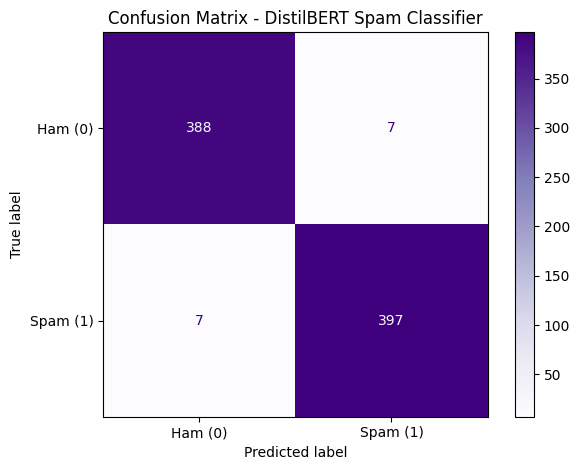

📁 Saved CM to: /content/drive/MyDrive/bertmixeddataset/distilbert_confusion_matrix.png


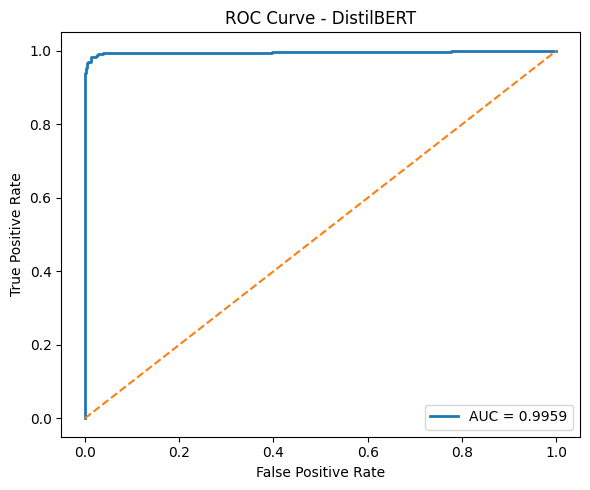

📁 Saved ROC to: /content/drive/MyDrive/bertmixeddataset/distilbert_roc_curve.png

📋 Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.98      0.98       395
        Spam       0.98      0.98      0.98       404

    accuracy                           0.98       799
   macro avg       0.98      0.98      0.98       799
weighted avg       0.98      0.98      0.98       799



In [ ]:
# ==========================================
# 📊 CONFUSION MATRIX + ROC CURVE for YOUR TRAINED DISTILBERT
# (Aligned exactly with training pipeline)
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

import os, re, torch, numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, classification_report
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from sklearn.model_selection import train_test_split
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 1️⃣ Load YOUR trained model
# -----------------------------
model_path = "/content/drive/MyDrive/bertmixeddataset/distilbertfolder"
model = DistilBertForSequenceClassification.from_pretrained(model_path)
tokenizer = DistilBertTokenizerFast.from_pretrained(model_path)

model.to(device)
model.eval()

print("✅ Loaded trained DistilBERT from:", model_path)

# -----------------------------
# 2️⃣ Load SAME dataset used in training
# -----------------------------
file_path = "/content/drive/MyDrive/data2/mixeddataset.xlsx"
df = pd.read_excel(file_path)

def preprocess_text(text):
    text = re.sub(r'[^\x00-\x7F]+', ' ', str(text))
    text = re.sub(r'\s+', ' ', text).strip()
    return ' '.join(text.split()[:500])

df['subject'] = df['subject'].astype(str).apply(preprocess_text)
df['body'] = df['body'].astype(str).apply(preprocess_text)
df['text'] = (df['subject'] + " " + df['body']).str.strip()

df = df.dropna(subset=['text', 'label'])
df = df[df['text'].str.strip() != '']
df = df[~df['text'].str.contains('#ERROR!', na=False)]
df = df.drop_duplicates(subset=['text']).reset_index(drop=True)

# -----------------------------
# 3️⃣ Same validation split
# -----------------------------
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

texts = val_df['text'].tolist()
labels = val_df['label'].tolist()

print(f"✅ Validation samples: {len(val_df)}")

# -----------------------------
# 4️⃣ Batched prediction (512 tokens like training)
# -----------------------------
batch_size = 16
all_preds, all_probs = [], []

for i in tqdm(range(0, len(texts), batch_size), desc="Evaluating"):
    batch_texts = texts[i:i+batch_size]

    encodings = tokenizer(
        batch_texts,
        truncation=True,
        padding=True,
        max_length=512,
        return_tensors='pt'
    ).to(device)

    with torch.no_grad():
        outputs = model(**encodings)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = torch.argmax(logits, dim=1).cpu().numpy()

    all_probs.extend(probs)
    all_preds.extend(preds)

probs = np.array(all_probs)
preds = np.array(all_preds)

# -----------------------------
# 5️⃣ Confusion Matrix
# -----------------------------
cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Ham (0)", "Spam (1)"])

plt.figure(figsize=(6,5))
disp.plot(cmap="Purples", values_format="d")
plt.title("Confusion Matrix - DistilBERT Spam Classifier")
plt.tight_layout()

cm_path = "/content/drive/MyDrive/bertmixeddataset/distilbert_confusion_matrix.png"
plt.savefig(cm_path, dpi=300)
plt.show()

print("📁 Saved CM to:", cm_path)

# -----------------------------
# 6️⃣ ROC Curve
# -----------------------------
fpr, tpr, _ = roc_curve(labels, probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - DistilBERT")
plt.legend()
plt.tight_layout()

roc_path = "/content/drive/MyDrive/bertmixeddataset/distilbert_roc_curve.png"
plt.savefig(roc_path, dpi=300)
plt.show()

print("📁 Saved ROC to:", roc_path)

# -----------------------------
# 7️⃣ Classification Report
# -----------------------------
print("\n📋 Classification Report:")
print(classification_report(labels, preds, target_names=["Ham", "Spam"]))


In [ ]:
!pip install -q lime



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from lime.lime_text import LimeTextExplainer
print("✅ LIME is ready to use")


✅ LIME is ready to use


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ DistilBERT model loaded successfully
Type 'exit' as subject to stop testing

Enter email subject: Dear, nandanaanandp@gmail.com!
Enter email body: We are pleased to inform you that your previously lost funds from internet fraud have been reclaimed by the American government.  Your funds and ROI have been deposited with a Credit Union. Please reply to this message and provide your full name and INC ID for assistance with your deposit.  Your deposit request ID: INC  Best regards, Stephen Laurance American Federal Trade Commission

🔍 Prediction: Phishing Email
📊 Confidence: 99.04 %

🧠 LIME Explanation (Feature Importance):


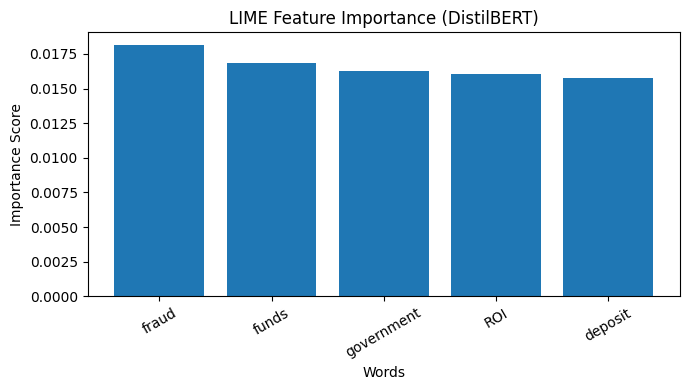


📌 Top Influential Words:
fraud                → 0.0182
funds                → 0.0169
government           → 0.0163
ROI                  → 0.0160
deposit              → 0.0158


Enter email subject: exit
🛑 Testing stopped


In [ ]:
# ================================
# Step 1: Mount Google Drive
# ================================
from google.colab import drive
drive.mount('/content/drive')

# ================================
# Step 2: Imports
# ================================
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification
)
import torch
import torch.nn.functional as F
from lime.lime_text import LimeTextExplainer
import matplotlib.pyplot as plt
import os

# ================================
# Step 3: Load trained DistilBERT model
# ================================
model_path = "/content/drive/MyDrive/bertmixeddataset/distilbertfolder"

assert os.path.exists(model_path), "❌ DistilBERT model folder not found!"

tokenizer = DistilBertTokenizerFast.from_pretrained(
    model_path,
    local_files_only=True
)

model = DistilBertForSequenceClassification.from_pretrained(
    model_path,
    local_files_only=True
)

model.eval()

print("✅ DistilBERT model loaded successfully")
print("Type 'exit' as subject to stop testing\n")

# ================================
# Step 4: LIME setup
# ================================
class_names = ["Legitimate Email", "Phishing Email"]
explainer = LimeTextExplainer(class_names=class_names)

# ================================
# Step 5: Prediction function for LIME
# ================================
def predict_proba(texts):
    inputs = tokenizer(
        texts,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )

    with torch.no_grad():
        outputs = model(**inputs)

    probs = F.softmax(outputs.logits, dim=1)
    return probs.cpu().numpy()

# ================================
# Step 6: Interactive Testing Loop
# ================================
while True:
    subject = input("Enter email subject: ")
    if subject.lower() == "exit":
        print("🛑 Testing stopped")
        break

    body = input("Enter email body: ")
    text = subject + " " + body

    # Tokenize input
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=512
    )

    # Model prediction
    with torch.no_grad():
        outputs = model(**inputs)

    probs = torch.softmax(outputs.logits, dim=1)
    pred = torch.argmax(probs, dim=1).item()
    confidence = probs[0][pred].item()

    label = "Phishing Email" if pred == 1 else "Legitimate Email"

    print("\n🔍 Prediction:", label)
    print("📊 Confidence:", round(confidence * 100, 2), "%")

    # ================================
    # Step 7: LIME Explanation (BAR CHART)
    # ================================
    print("\n🧠 LIME Explanation (Feature Importance):")

    explanation = explainer.explain_instance(
        text,
        predict_proba,
        num_features=5,
        num_samples=300,
        labels=[pred]
    )

    # Extract LIME results
    exp = explanation.as_list(label=pred)

    words = [w for w, s in exp]
    scores = [abs(s) for w, s in exp]

    # 📊 Bar chart
    plt.figure(figsize=(7, 4))
    plt.bar(words, scores)
    plt.xlabel("Words")
    plt.ylabel("Importance Score")
    plt.title("LIME Feature Importance (DistilBERT)")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    # 📝 Text explanation
    print("\n📌 Top Influential Words:")
    for word, weight in exp:
        print(f"{word:20s} → {weight:.4f}")

    print("\n" + "=" * 60 + "\n")
